
# **ML Boosting Algorityhm**

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# EDA

## Paso 1: Carga del conjunto de datos

In [36]:
# Carga de los datos (ajusta la ruta si es necesario)
df = pd.read_csv("../data/processed/diabetes_eda (1).csv")

In [37]:
df.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 42.1 KB


**Outcome:**

| valor | significado |
| ----- | ----------- |
| 0     | No diabetes |
| 1     | Diabetes    |


### Split Data

In [39]:
# Separación de características (X) y variable objetivo (y)
# En el dataset, 'Outcome' indica si tiene diabetes o no [5]
X = df.drop("Outcome", axis = 1)
y = df["Outcome"]

## Paso 2: División en muestras de entrenamiento (train) y prueba (test)


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

## Paso 3: Construir el modelo de Boosting

Para este paso utilizaremos la librería XGBoost, que es la implementación más eficiente del algoritmo de gradient boosting

* **Inicialización y entrenamiento del modelo añadiendo el parámetro eval_metric**


In [41]:
model = XGBClassifier(random_state=42,eval_metric="logloss")
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

* **Predicción y análisis de resultados iniciales**

In [42]:
y_pred = model.predict(X_test)


In [43]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)

Accuracy: 0.7532467532467533
Precision: 0.66
Recall: 0.6111111111111112
F1 score: 0.6346153846153846


### Matriz de Confusión

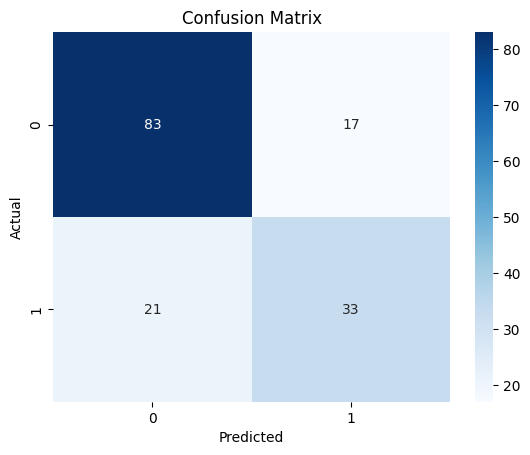

In [44]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

> **Observaciones:**  
Info real predecida  
> VN = 83, pacientes sin diabetes identificados en el grupo correcto. 
> FP  = 17, pacientes detectados sanos pero no lo son, si tienen diabetes.
> FN  = 21, pacientes diabeticos detectados como no diabeticos.
> VP = 33, pacientes diabeticos detectados correctamente  

* Columna izquierda = pacientes no diabeticos (VN y  FN)
* Columna dercha = pacientes diabticos (FP y VP) 
* Fila 83, 17 = 

## Paso 4: Optimización de hiperparámetros

In [45]:
model_optimized = XGBClassifier(n_estimators = 100,learning_rate = 0.1,max_depth = 5,random_state = 42) # Prueba modificando valores como n_estimators, learning_rate y max_depth 


* **Entrenamiento del modelo optimizado:**

In [46]:

model_optimized.fit(X_train, y_train)
y_pred_opt = model_optimized.predict(X_test)
print(f"Accuracy optimizado: {accuracy_score(y_test, y_pred_opt)}")

Accuracy optimizado: 0.7792207792207793


* **Comparación el modelo optimizado:**

In [47]:
results = {"XGBoost Default": accuracy_score(y_test, y_pred),"XGBoost Optimized": accuracy_score(y_test, y_pred_opt)}
results

{'XGBoost Default': 0.7532467532467533,
 'XGBoost Optimized': 0.7792207792207793}

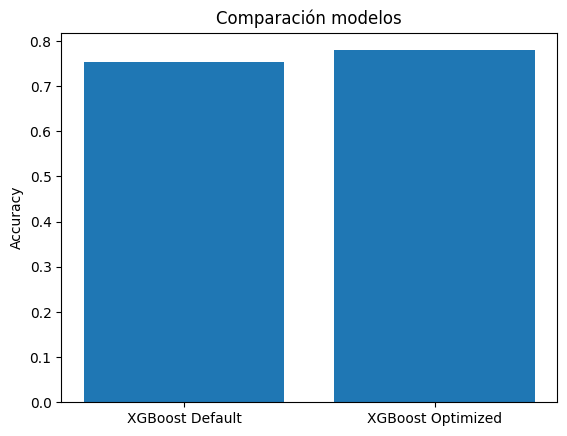

In [48]:
plt.bar(results.keys(), results.values())
plt.title("Comparación modelos")
plt.ylabel("Accuracy")
plt.show()

* **Variables destacadas:**

In [49]:
importances = model_optimized.feature_importances_
importance_df = pd.DataFrame({"feature": X.columns,"importance": importances}).sort_values("importance", ascending=False)
importance_df

,feature,importance
1,Glucose,0.336136
3,BMI,0.179672
5,Age,0.150304
0,Pregnancies,0.114870
4,DiabetesPedigreeFunction,0.114413
2,BloodPressure,0.104604


## Paso 5: Guarda el modelo

Es vital almacenar el modelo entrenado con un nombre explicativo que incluya la configuración o la semilla utilizada para asegurar la replicabilidad

In [50]:
model_optimized.save_model("xgb_diabetes_optimized_42.json")

## Conclusiones finales

* Se utilizó el algoritmo XGBoost, un método basado en boosting que construye modelos secuenciales para mejorar el rendimiento predictivo. El modelo alcanzó una accuracy aproximada del 75%, mostrando una capacidad razonable para clasificar correctamente a los pacientes.

* El análisis de métricas adicionales como precision, recall y F1 score permite evaluar mejor el rendimiento del modelo, especialmente en aplicaciones médicas donde detectar correctamente los casos positivos es fundamental. El ajuste de hiperparámetros permitió mejorar ligeramente el rendimiento del modelo.

* En conclusión, XGBoost se muestra como una herramienta potente para problemas de clasificación médica, aunque el rendimiento podría mejorarse con más optimización o ingeniería de características.

DUDA: Con qué metricas trabajo?

DUDA: qué reportes o conclusiones saco?



DUDA: que le falta al proyecto para estar completo?

DUDA: como desemvolupo el paso 4??

Falta responder DUDA: revisar en chat y sacar apuntes